# Triple Barrier Labeling — WTI Crude Oil (CL1S)

This notebook applies the **Triple Barrier Method** (Lopez de Prado, 2018) to the WTI Crude Oil
continuous futures contract (`cl1s`) using the primary model signals provided in `primary_signals.csv`.

## Pipeline
1. Load and inspect the oil price data
2. Estimate daily volatility (multiple estimators)
3. Set up the three barriers (take-profit, stop-loss, vertical time limit)
4. Label each signal event
5. Analyse the label distribution and trade-level statistics
6. Sensitivity analysis: vary barrier widths and time horizon

## Module structure
```
code/labels/
├── volatility.py   — daily volatility estimators
├── barriers.py     — barrier level construction
├── labeler.py      — first-touch labeling engine
└── visualize.py    — plotting utilities
```

In [9]:
import sys
from pathlib import Path

ROOT = Path.cwd()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "data" / "raw").exists():
        ROOT = candidate
        break

LABEL_CODE_DIR = ROOT / "code" / "labels"
if str(LABEL_CODE_DIR) not in sys.path:
    sys.path.insert(0, str(LABEL_CODE_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['axes.grid'] = True
matplotlib.rcParams['grid.alpha'] = 0.3

from volatility import ewma_daily_vol, rolling_daily_vol, parkinson_daily_vol, garman_klass_daily_vol
from barriers import barrier_levels, vertical_barrier, filter_events_by_cusum
from labeler import get_labels, label_events, label_summary
from visualize import (
    plot_label_distribution,
    plot_barrier_examples,
    plot_labels_on_price,
    plot_return_distribution,
    plot_volatility,
)

print('All modules loaded.')

All modules loaded.


## 1. Load data

In [10]:
RAW_DATA_DIR = ROOT / "data" / "raw"

ohlcv = pd.read_csv(RAW_DATA_DIR / "ohlcv_data.csv", parse_dates=['date']).set_index('date')
signals_all = pd.read_csv(RAW_DATA_DIR / "primary_signals.csv", parse_dates=['date']).set_index('date')

# ── Oil-only slice ──────────────────────────────────────────────────────────
oil = ohlcv[ohlcv['instrument'] == 'cl1s'].copy()
oil = oil.sort_index()

close = oil['close']
high  = oil['high']
low   = oil['low']
open_ = oil['open']

# Primary signal for CL1S (available from Jan 2020)
signal_cl1s = signals_all['cl1s']

print(f'Oil price history : {close.index.min().date()} → {close.index.max().date()} ({len(close):,} days)')
print(f'Primary signal    : {signal_cl1s.index.min().date()} → {signal_cl1s.index.max().date()} ({len(signal_cl1s):,} days)')
print(f'\nSignal distribution:\n{signal_cl1s.value_counts().sort_index()}')

Oil price history : 1990-01-02 → 2022-06-30 (8,171 days)
Primary signal    : 2020-01-03 → 2022-06-30 (645 days)

Signal distribution:
cl1s
-1     36
 0    223
 1    386
Name: count, dtype: int64


## 2. Volatility estimation

We compare four estimators:
- **EWMA close-to-close** — recommended by Lopez de Prado; most responsive to recent vol
- **Rolling close-to-close** — simple 20-day equal-weighted std
- **Parkinson** — range-based; ~5× more efficient than close-to-close
- **Garman-Klass** — uses OHLC; most efficient of the four

We use EWMA as the default for barrier calibration because it adapts quickly to
regime changes in crude oil (supply shocks, geopolitical events).

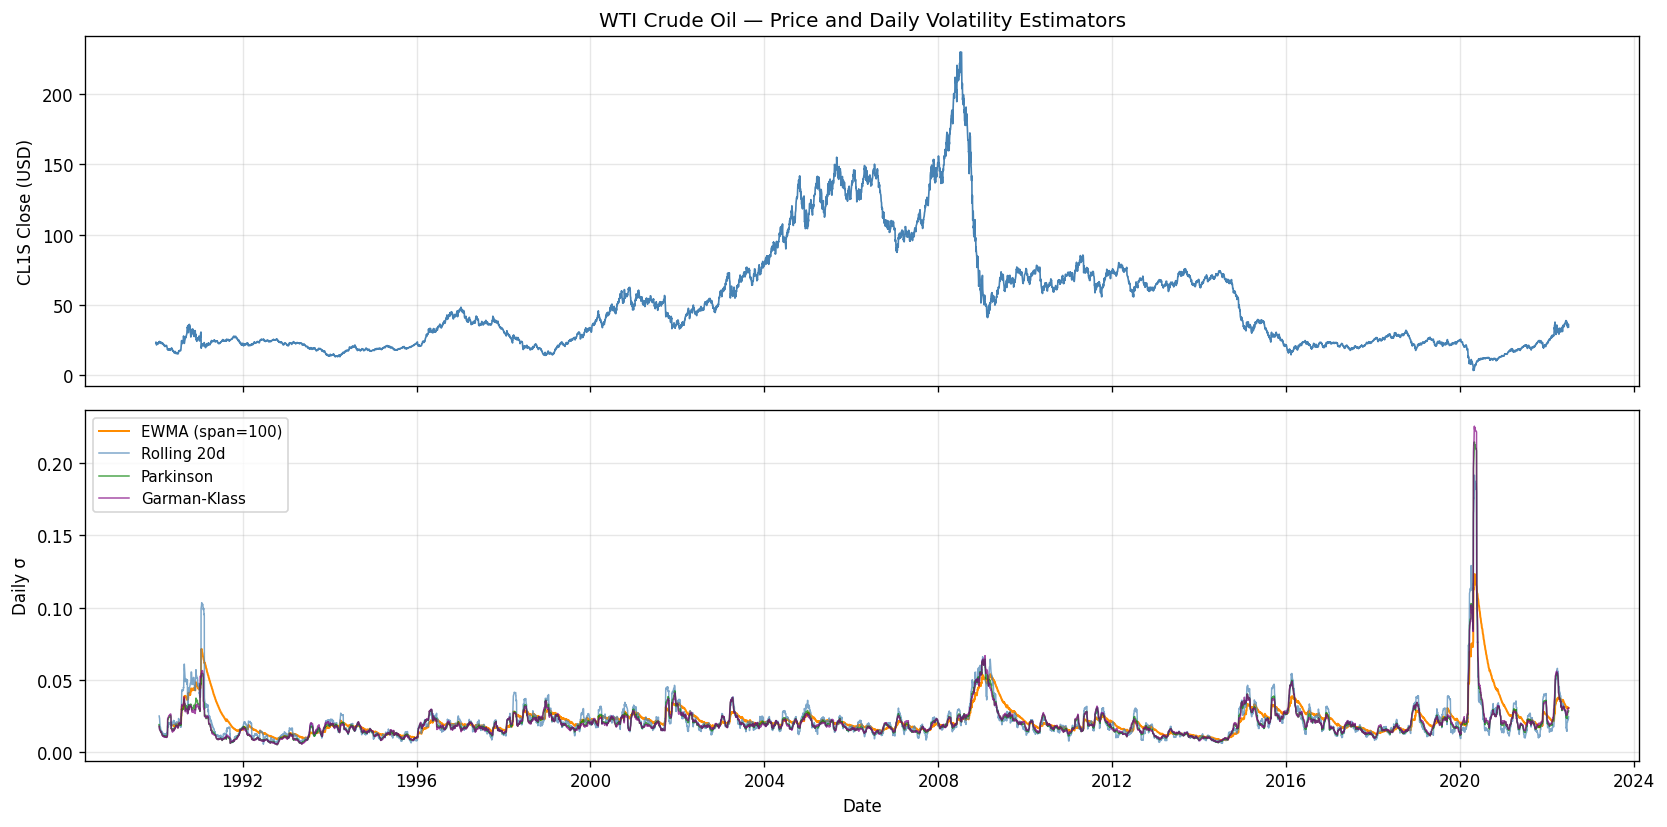


Correlation between vol estimators (2020 onwards):
               EWMA  Rolling  Parkinson  Garman-Klass
EWMA          1.000    0.706      0.730         0.731
Rolling       0.706    1.000      0.979         0.970
Parkinson     0.730    0.979      1.000         0.999
Garman-Klass  0.731    0.970      0.999         1.000


In [11]:
# ── Compute all four estimators ─────────────────────────────────────────────
VOL_SPAN   = 100   # EWMA span for daily vol
VOL_WINDOW = 20    # rolling window

vol_ewma = ewma_daily_vol(close, span=VOL_SPAN)
vol_roll = rolling_daily_vol(close, window=VOL_WINDOW)
vol_park = parkinson_daily_vol(high, low, window=VOL_WINDOW)
vol_gk   = garman_klass_daily_vol(open_, high, low, close, window=VOL_WINDOW)

# ── Plot ────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ax1.plot(close, color='steelblue', lw=1)
ax1.set_ylabel('CL1S Close (USD)')
ax1.set_title('WTI Crude Oil — Price and Daily Volatility Estimators')

ax2.plot(vol_ewma, label=f'EWMA (span={VOL_SPAN})', lw=1.2, color='darkorange')
ax2.plot(vol_roll, label=f'Rolling {VOL_WINDOW}d', lw=0.9, color='steelblue', alpha=0.7)
ax2.plot(vol_park, label='Parkinson', lw=0.9, color='green', alpha=0.7)
ax2.plot(vol_gk,   label='Garman-Klass', lw=0.9, color='purple', alpha=0.7)
ax2.set_ylabel('Daily σ')
ax2.set_xlabel('Date')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Correlation between estimators
vol_df = pd.DataFrame({'EWMA': vol_ewma, 'Rolling': vol_roll, 'Parkinson': vol_park, 'Garman-Klass': vol_gk})
print('\nCorrelation between vol estimators (2020 onwards):')
print(vol_df.loc['2020':].corr().round(3))

## 3. Barrier construction

### Parameter choices

| Parameter | Value | Justification |
|-----------|-------|---------------|
| `pt_multiplier` | 1.5 | Slightly wider TP than SL — crude oil trends tend to persist |
| `sl_multiplier` | 1.0 | Symmetric SL at 1σ to limit downside exposure |
| `num_days` | 10 | ~2 trading weeks; balances sufficient time to play out vs. avoiding stale positions |
| Vol estimator | EWMA span=100 | Adapts to oil vol regimes without overreacting to noise |

These are the *baseline* parameters.  Section 6 runs a sensitivity analysis.

In [12]:
# ── Baseline barrier parameters ──────────────────────────────────────────────
PT_MULT  = 1.5   # take-profit multiplier
SL_MULT  = 1.0   # stop-loss multiplier
NUM_DAYS = 10    # vertical barrier (trading days)

daily_vol = vol_ewma  # chosen estimator

# ── Events = non-zero signal dates ───────────────────────────────────────────
t_events = signal_cl1s[signal_cl1s != 0].index
t_events = t_events[t_events.isin(close.index)]  # filter to available price dates
side     = signal_cl1s.reindex(t_events).astype(float)

print(f'Total signal events (non-zero): {len(t_events)}')
print(f'Long (+1) : {(side == 1).sum()}')
print(f'Short (-1): {(side == -1).sum()}')

# ── Build barrier table ───────────────────────────────────────────────────────
events = barrier_levels(
    close=close,
    t_events=t_events,
    daily_vol=daily_vol,
    pt_multiplier=PT_MULT,
    sl_multiplier=SL_MULT,
    num_days=NUM_DAYS,
    side=side,
)

print(f'\nBarrier table (first 5 rows):')
display(events.head())

Total signal events (non-zero): 422
Long (+1) : 386
Short (-1): 36

Barrier table (first 5 rows):


,t1,pt,sl,vol,side,entry_price
date,,,,,,
2020-01-07,2020-01-22,24.664421,25.909749,0.019602,-1.0,25.411618
2020-01-22,2020-02-05,22.307294,23.435562,0.019635,-1.0,22.984255
2020-01-23,2020-02-06,21.854975,22.960704,0.019641,-1.0,22.518412
2020-01-24,2020-02-07,21.300989,22.384840,0.019750,-1.0,21.951300
2020-01-27,2020-02-10,20.889242,21.950448,0.019720,-1.0,21.525966


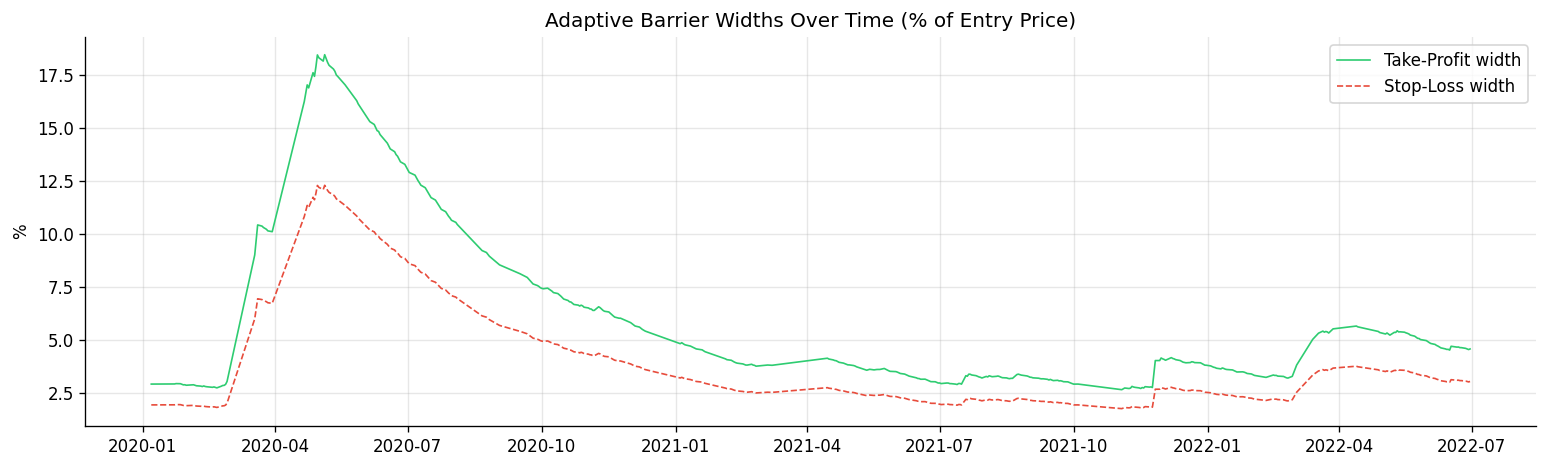

Median TP width: 4.05%
Median SL width: 2.70%


In [13]:
# ── Visualise barrier widths over time ────────────────────────────────────────
barrier_pct = pd.DataFrame({
    'TP width (%)': abs(events['pt'] / events['entry_price'] - 1) * 100,
    'SL width (%)': abs(events['sl'] / events['entry_price'] - 1) * 100,
})

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(barrier_pct['TP width (%)'], label='Take-Profit width', color='#2ecc71', lw=1)
ax.plot(barrier_pct['SL width (%)'], label='Stop-Loss width',   color='#e74c3c', lw=1, linestyle='--')
ax.set_title('Adaptive Barrier Widths Over Time (% of Entry Price)')
ax.set_ylabel('%')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print(f'Median TP width: {barrier_pct["TP width (%)"].median():.2f}%')
print(f'Median SL width: {barrier_pct["SL width (%)"].median():.2f}%')

## 4. Label events

In [14]:
labels = label_events(close=close, events=events)

print(f'Total labelled events: {len(labels)}')
print(f'\nLabel distribution:')
display(label_summary(labels))

Total labelled events: 422

Label distribution:


,count,mean_ret,std_ret,proportion
label,,,,
Stop-Loss (-1),166,-0.047394,0.035734,0.394299
Time-Out (0),0,NaN,NaN,0.000000
Take-Profit (+1),255,0.059017,0.047083,0.605701


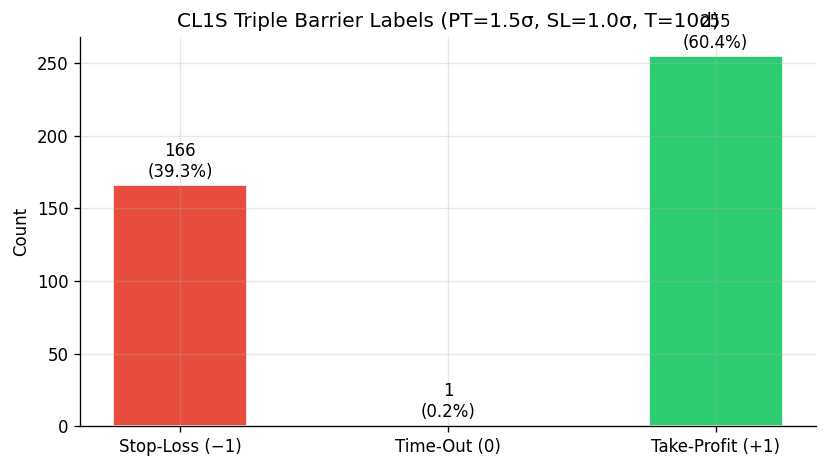

In [15]:
plot_label_distribution(
    labels,
    title=f'CL1S Triple Barrier Labels (PT={PT_MULT}σ, SL={SL_MULT}σ, T={NUM_DAYS}d)'
)

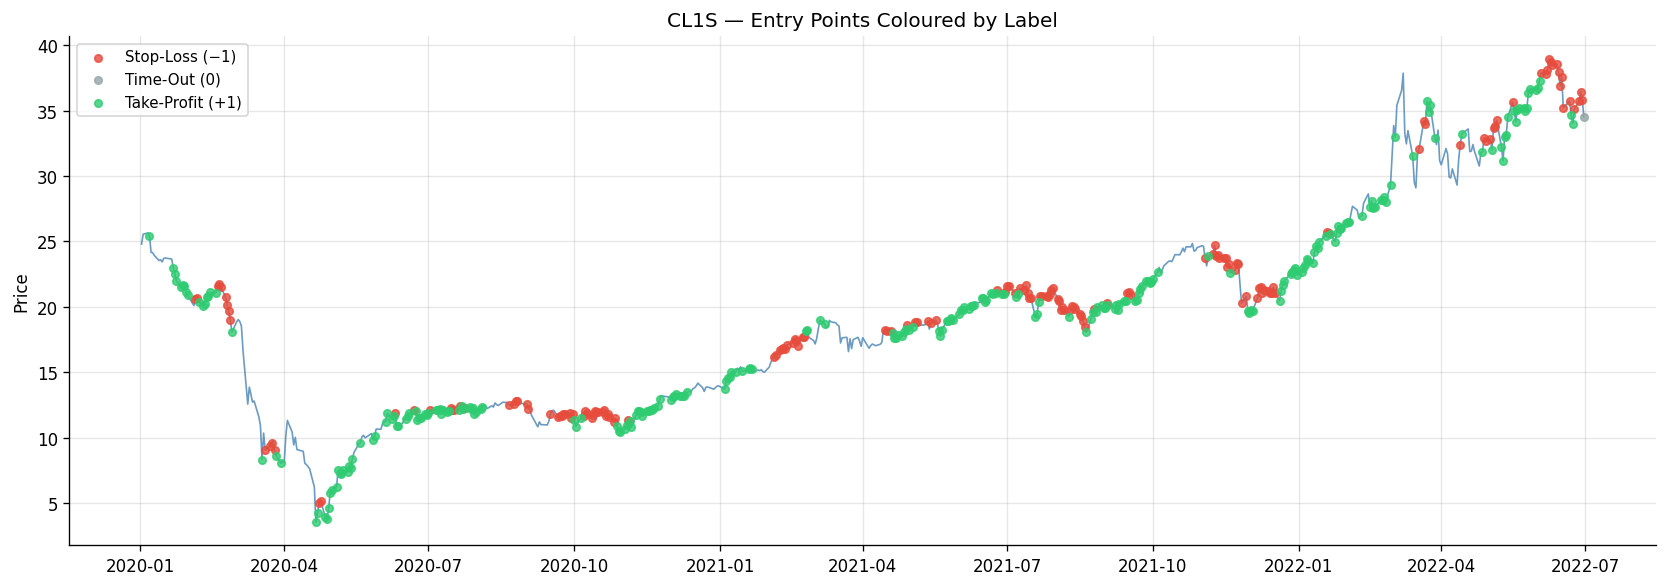

In [16]:
plot_labels_on_price(
    close=close,
    labels=labels,
    title='CL1S — Entry Points Coloured by Label',
    start='2020-01-01',
)

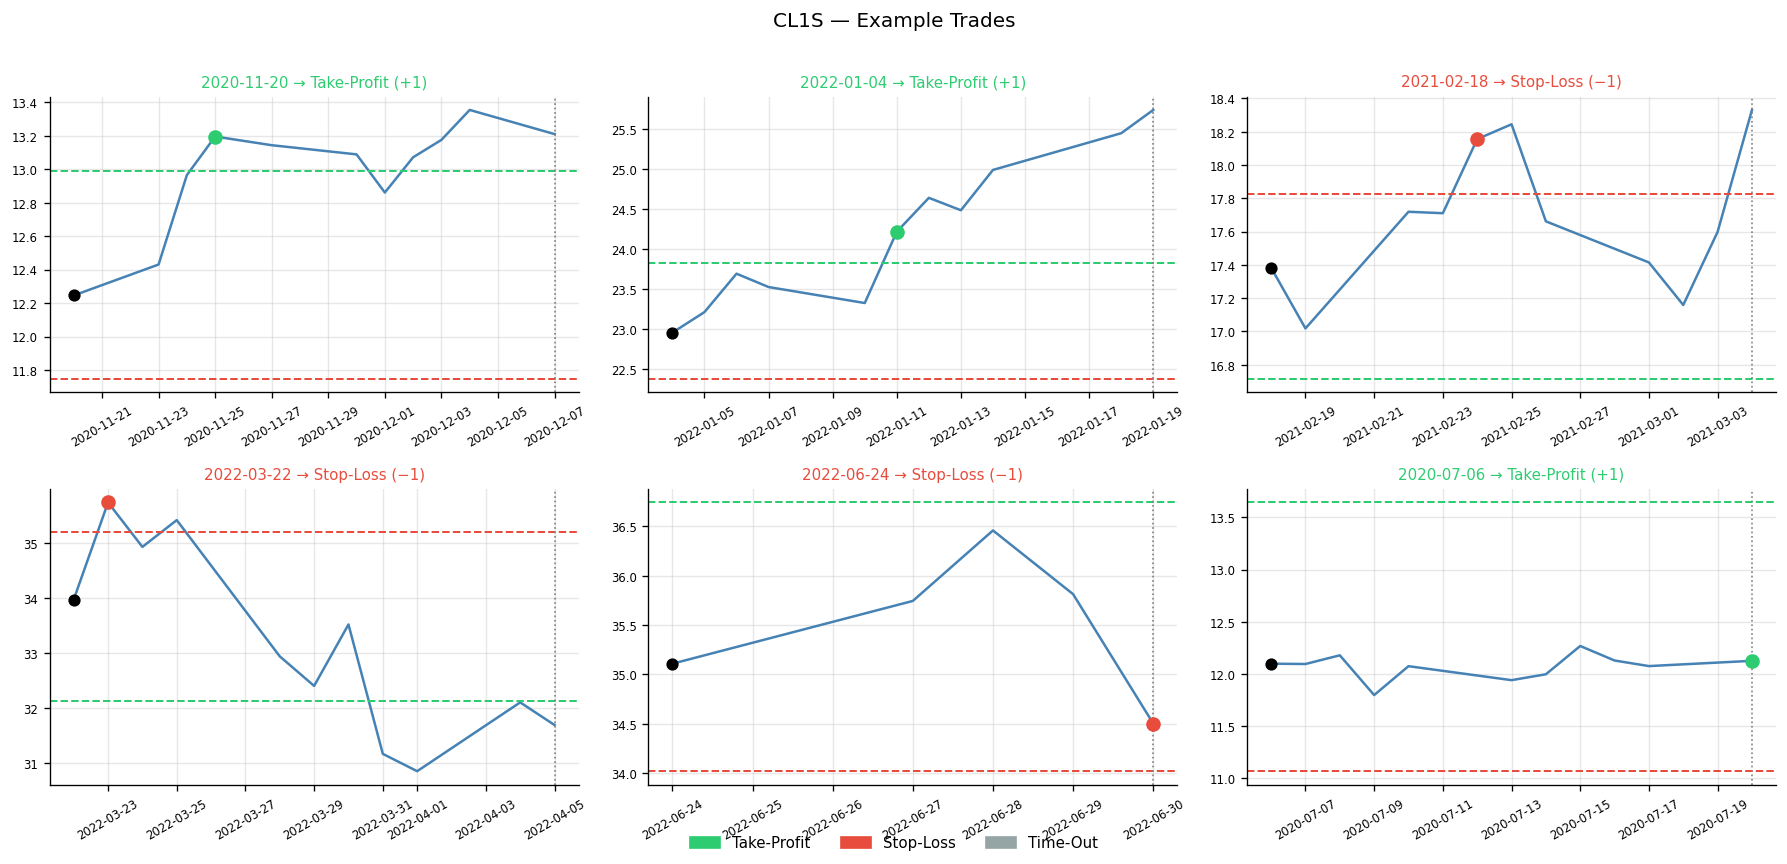

In [17]:
plot_barrier_examples(
    close=close,
    labels=labels,
    n_examples=6,
    title_prefix='CL1S',
)

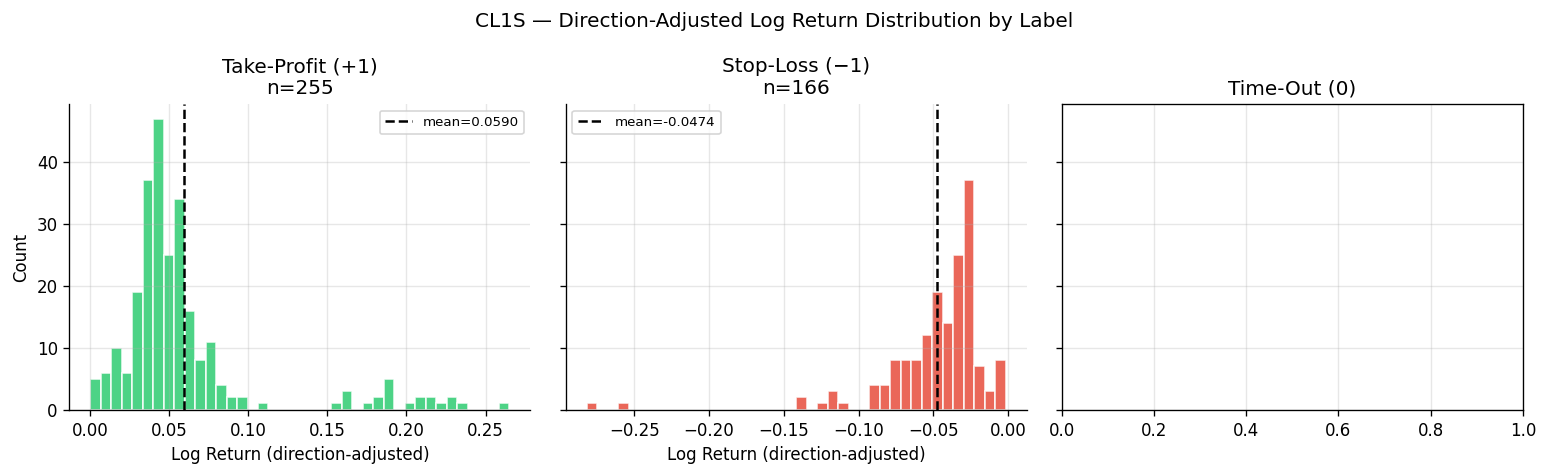

In [18]:
plot_return_distribution(
    labels,
    title='CL1S — Direction-Adjusted Log Return Distribution by Label'
)

## 5. Trade-level statistics

In [19]:
# Holding period (trading days from entry to first touch)
labels['holding_days'] = (labels['touch_date'] - labels.index).dt.days

# Win rate = fraction of events labelled +1
win_rate = (labels['label'] == 1).mean()
avg_win  = labels.loc[labels['label'] ==  1, 'ret'].mean()
avg_loss = labels.loc[labels['label'] == -1, 'ret'].mean()

print(f'Win rate (TP hit):          {win_rate:.1%}')
print(f'Average winning trade ret:  {avg_win:.4f}')
print(f'Average losing trade ret:   {avg_loss:.4f}')
print(f'Win/Loss ratio:             {abs(avg_win / avg_loss):.2f}x')
print()

print('Average holding period by label (calendar days):')
print(labels.groupby('label')['holding_days'].mean().rename(index={-1: 'SL', 0: 'TO', 1: 'TP'}).round(1))

Win rate (TP hit):          60.4%
Average winning trade ret:  0.0590
Average losing trade ret:   -0.0474
Win/Loss ratio:             1.25x

Average holding period by label (calendar days):
label
SL    6.2
TO    NaN
TP    8.3
Name: holding_days, dtype: float64


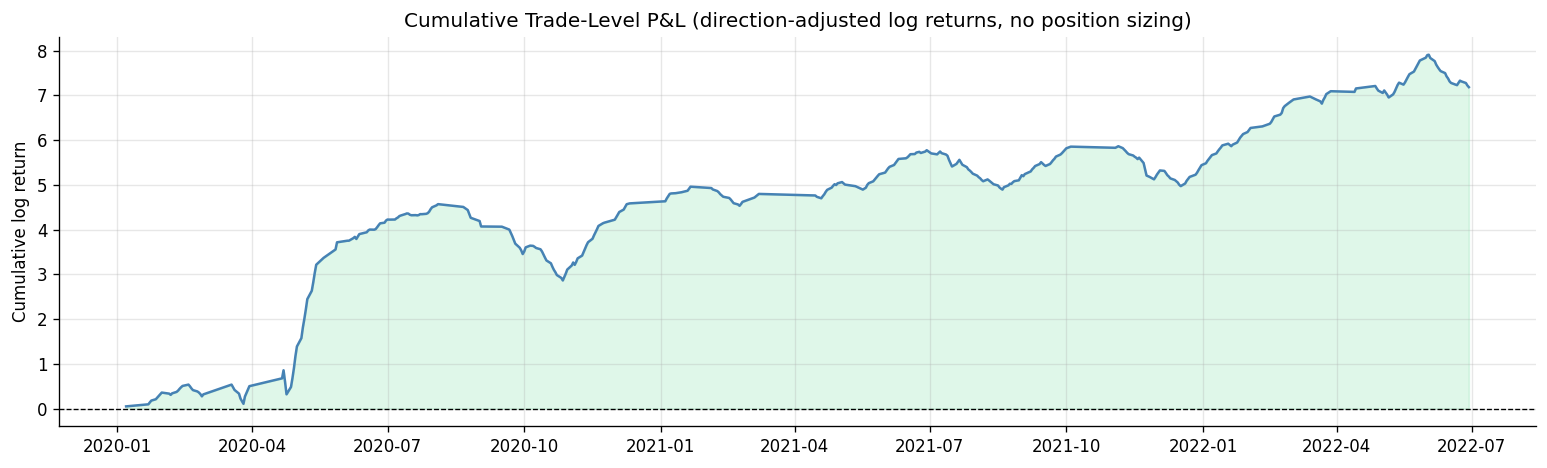

In [20]:
# Cumulative P&L if we follow every signal (naive, unscaled)
labels_sorted = labels.sort_index()
cum_ret = labels_sorted['ret'].cumsum()

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(labels_sorted.index, cum_ret, color='steelblue', lw=1.5)
ax.axhline(0, color='black', lw=0.8, linestyle='--')
ax.fill_between(labels_sorted.index, 0, cum_ret, where=(cum_ret >= 0), alpha=0.15, color='#2ecc71')
ax.fill_between(labels_sorted.index, 0, cum_ret, where=(cum_ret < 0),  alpha=0.15, color='#e74c3c')
ax.set_title('Cumulative Trade-Level P&L (direction-adjusted log returns, no position sizing)')
ax.set_ylabel('Cumulative log return')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## 6. Sensitivity analysis — barrier parameter grid

Vary `pt_multiplier`, `sl_multiplier`, and `num_days` to understand how the
label distribution and expected return change.  This informs the final
parameter choice used for the metamodel labels.

In [21]:
from itertools import product

pt_grid   = [0.5, 1.0, 1.5, 2.0]
sl_grid   = [0.5, 1.0, 1.5]
day_grid  = [5, 10, 20]

rows = []
for pt_m, sl_m, nd in product(pt_grid, sl_grid, day_grid):
    ev = barrier_levels(
        close=close, t_events=t_events, daily_vol=daily_vol,
        pt_multiplier=pt_m, sl_multiplier=sl_m, num_days=nd, side=side,
    )
    lb = label_events(close=close, events=ev)
    n  = len(lb)
    rows.append({
        'PT mult': pt_m,
        'SL mult': sl_m,
        'Days':    nd,
        'N':       n,
        'TP (%)':  round(100 * (lb['label'] == 1).mean(), 1),
        'SL (%)':  round(100 * (lb['label'] == -1).mean(), 1),
        'TO (%)':  round(100 * (lb['label'] == 0).mean(), 1),
        'Mean ret': round(lb['ret'].mean(), 4),
    })

grid_df = pd.DataFrame(rows)
print(f'Grid size: {len(grid_df)} combinations')
display(grid_df.sort_values('Mean ret', ascending=False).head(15))

Grid size: 36 combinations


,PT mult,SL mult,Days,N,TP (%),SL (%),TO (%),Mean ret
35,2.0,1.5,20,422,64.2,35.5,0.2,0.0241
34,2.0,1.5,10,422,65.9,33.9,0.2,0.0238
32,2.0,1.0,20,422,56.9,42.9,0.2,0.0217
31,2.0,1.0,10,422,58.5,41.2,0.2,0.0212
29,2.0,0.5,20,422,48.6,51.2,0.2,0.0208
26,1.5,1.5,20,422,67.5,32.2,0.2,0.0195
25,1.5,1.5,10,422,67.8,32.0,0.2,0.0194
28,2.0,0.5,10,422,50.2,49.5,0.2,0.0190
23,1.5,1.0,20,422,60.4,39.3,0.2,0.0176
22,1.5,1.0,10,422,60.4,39.3,0.2,0.0171


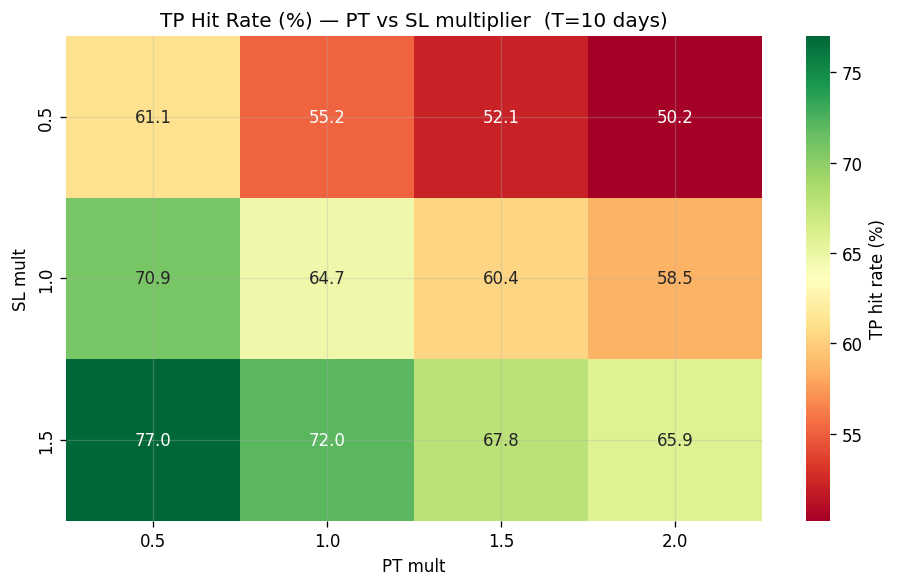

In [22]:
# ── Heatmap: TP% as a function of PT and SL multipliers (fixed num_days=10) ──
import matplotlib.pyplot as plt
import seaborn as sns

subset = grid_df[grid_df['Days'] == 10].pivot(index='SL mult', columns='PT mult', values='TP (%)')

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(subset, annot=True, fmt='.1f', cmap='RdYlGn', ax=ax,
            cbar_kws={'label': 'TP hit rate (%)'})
ax.set_title('TP Hit Rate (%) — PT vs SL multiplier  (T=10 days)')
plt.tight_layout()
plt.show()

## 7. Export labels

Save the baseline labels as a CSV for use in the Feature Engineering and
Model Development stages.

In [23]:
export = labels[['label', 'ret', 'touch_date', 't1', 'pt', 'sl', 'vol', 'side', 'entry_price']].copy()
export.index.name = 'date'
export['instrument'] = 'cl1s'

out_path = ROOT / 'data' / 'labels' / 'labels_cl1s.csv'
export.to_csv(out_path)
print(f'Labels saved to {out_path}')
print(f'Shape: {export.shape}')
display(export.head())

Labels saved to /Users/faisal/Desktop/systematic-trading-coursework/data/labels/labels_cl1s.csv
Shape: (422, 10)


,label,ret,touch_date,t1,pt,sl,vol,side,entry_price,instrument
date,,,,,,,,,,
2020-01-07,1,0.050538,2020-01-08,2020-01-22,24.664421,25.909749,0.019602,-1.0,25.411618,cl1s
2020-01-22,1,0.045983,2020-01-24,2020-02-05,22.307294,23.435562,0.019635,-1.0,22.984255,cl1s
2020-01-23,1,0.045073,2020-01-27,2020-02-06,21.854975,22.960704,0.019641,-1.0,22.518412,cl1s
2020-01-24,1,0.038564,2020-01-30,2020-02-07,21.300989,22.384840,0.019750,-1.0,21.951300,cl1s
2020-01-27,1,0.030184,2020-01-31,2020-02-10,20.889242,21.950448,0.019720,-1.0,21.525966,cl1s


## 8. Clean enriched triple-barrier event output

The existing notebook output is kept unchanged. This section creates a new, clearer event-level file where `t0` is the entry date, `t1` is the actual exit date, and `vertical_t1` is the maximum holding date. It also stores raw and side-adjusted percentage returns.

Neutral primary-signal rows are retained for inspection. Their `position_side` is `0`, so their `position_return_pct` is `0.0`; they can be dropped later if the modelling dataset should contain active trades only.

In [24]:
def calculate_daily_volatility(
    close: pd.Series,
    high: pd.Series | None = None,
    low: pd.Series | None = None,
    open_: pd.Series | None = None,
    method: str = "ewma",
    span: int = 100,
    window: int = 20,
) -> pd.Series:
    """Calculate daily volatility for triple-barrier widths."""
    method = method.lower()
    if method == "ewma":
        return ewma_daily_vol(close, span=span)
    if method == "rolling":
        return rolling_daily_vol(close, window=window)
    if method == "parkinson":
        if high is None or low is None:
            raise ValueError("high and low are required for Parkinson volatility.")
        return parkinson_daily_vol(high, low, window=window)
    if method in {"garman_klass", "garman-klass", "gk"}:
        if open_ is None or high is None or low is None:
            raise ValueError("open_, high, and low are required for Garman-Klass volatility.")
        return garman_klass_daily_vol(open_, high, low, close, window=window)
    raise ValueError("method must be one of: ewma, rolling, parkinson, garman_klass")


def build_triple_barrier_events_with_returns(
    close: pd.Series,
    signal: pd.Series,
    high: pd.Series | None = None,
    low: pd.Series | None = None,
    open_: pd.Series | None = None,
    horizon: int = 10,
    take_profit_mult: float = 2.0,
    stop_loss_mult: float = 2.0,
    vol_method: str = "ewma",
    vol_span: int = 100,
    vol_window: int = 20,
    instrument: str = "cl1s",
) -> pd.DataFrame:
    """Build clean triple-barrier events with explicit entry, exit, and return fields."""
    close = close.dropna().sort_index()
    signal = signal.sort_index()
    daily_vol = calculate_daily_volatility(
        close=close,
        high=high.sort_index() if high is not None else None,
        low=low.sort_index() if low is not None else None,
        open_=open_.sort_index() if open_ is not None else None,
        method=vol_method,
        span=vol_span,
        window=vol_window,
    )

    event_frame = pd.DataFrame(
        {
            "entry_price": close,
            "primary_signal": signal,
            "vol": daily_vol,
        }
    ).dropna(subset=["entry_price", "primary_signal", "vol"])

    event_frame["primary_signal"] = event_frame["primary_signal"].astype(int)
    price_index = close.index
    event_positions = price_index.get_indexer(event_frame.index)
    vertical_positions = event_positions + horizon
    valid_horizon = (event_positions >= 0) & (vertical_positions < len(price_index))
    event_frame = event_frame.loc[valid_horizon].copy()
    vertical_positions = vertical_positions[valid_horizon]
    event_frame["vertical_t1"] = price_index[vertical_positions]

    rows = []
    for t0, row in event_frame.iterrows():
        primary_signal = int(row["primary_signal"])
        position_side = float(primary_signal)
        barrier_side = 1.0 if primary_signal == 0 else position_side
        entry_price = float(row["entry_price"])
        vol = float(row["vol"])
        vertical_t1 = row["vertical_t1"]

        pt = entry_price * (1 + barrier_side * take_profit_mult * vol) if take_profit_mult > 0 else np.nan
        sl = entry_price * (1 - barrier_side * stop_loss_mult * vol) if stop_loss_mult > 0 else np.nan

        price_path = close.loc[(close.index > t0) & (close.index <= vertical_t1)]
        barrier_outcome = "timeout"
        triple_barrier_label = 0
        t1 = vertical_t1
        exit_price = float(close.loc[vertical_t1])

        for current_date, current_close in price_path.items():
            current_close = float(current_close)
            if not np.isnan(pt):
                if barrier_side >= 0 and current_close >= pt:
                    barrier_outcome = "take_profit"
                    triple_barrier_label = 1
                    t1 = current_date
                    exit_price = current_close
                    break
                if barrier_side < 0 and current_close <= pt:
                    barrier_outcome = "take_profit"
                    triple_barrier_label = 1
                    t1 = current_date
                    exit_price = current_close
                    break
            if not np.isnan(sl):
                if barrier_side >= 0 and current_close <= sl:
                    barrier_outcome = "stop_loss"
                    triple_barrier_label = -1
                    t1 = current_date
                    exit_price = current_close
                    break
                if barrier_side < 0 and current_close >= sl:
                    barrier_outcome = "stop_loss"
                    triple_barrier_label = -1
                    t1 = current_date
                    exit_price = current_close
                    break

        raw_return_pct = (exit_price / entry_price - 1) * 100
        position_return_pct = position_side * raw_return_pct

        metalabel = 0.5
        if primary_signal != 0:
            if primary_signal == triple_barrier_label:
                metalabel = 1.0
            elif triple_barrier_label in [-1, 1] and primary_signal != triple_barrier_label:
                metalabel = 0.0

        rows.append(
            {
                "date": t0,
                "instrument": instrument,
                "t0": t0,
                "t1": t1,
                "vertical_t1": vertical_t1,
                "primary_signal": primary_signal,
                "position_side": position_side,
                "entry_price": entry_price,
                "exit_price": exit_price,
                "raw_return_pct": raw_return_pct,
                "position_return_pct": position_return_pct,
                "barrier_outcome": barrier_outcome,
                "triple_barrier_label": triple_barrier_label,
                "metalabel": metalabel,
                "pt": pt,
                "sl": sl,
                "vol": vol,
                "horizon": horizon,
                "pt_multiplier": take_profit_mult,
                "sl_multiplier": stop_loss_mult,
                "vol_method": vol_method,
            }
        )

    return pd.DataFrame(rows)


ENRICHED_HORIZON = 10
ENRICHED_PT_MULT = 1.5
ENRICHED_SL_MULT = 1
ENRICHED_VOL_METHOD = "ewma"
ENRICHED_VOL_SPAN = 100

triple_barrier_events_with_returns = build_triple_barrier_events_with_returns(
    close=close,
    signal=signal_cl1s,
    high=high,
    low=low,
    open_=open_,
    horizon=ENRICHED_HORIZON,
    take_profit_mult=ENRICHED_PT_MULT,
    stop_loss_mult=ENRICHED_SL_MULT,
    vol_method=ENRICHED_VOL_METHOD,
    vol_span=ENRICHED_VOL_SPAN,
    instrument="cl1s",
)

CL1_TRIPLE_BARRIER_EVENTS_WITH_RETURNS_PATH = ROOT / "data" / "triple_barrier" / "cl1_triple_barrier_events_with_returns.csv"
triple_barrier_events_with_returns.to_csv(CL1_TRIPLE_BARRIER_EVENTS_WITH_RETURNS_PATH, index=False)

print(f"Saved enriched triple-barrier events: {CL1_TRIPLE_BARRIER_EVENTS_WITH_RETURNS_PATH}")
print(f"Shape: {triple_barrier_events_with_returns.shape}")
print("Barrier outcome distribution:")
display(triple_barrier_events_with_returns["barrier_outcome"].value_counts().to_frame("count"))
print("Primary signal distribution:")
display(triple_barrier_events_with_returns["primary_signal"].value_counts().sort_index().to_frame("count"))
print("Sample enriched events:")
display(triple_barrier_events_with_returns.head())

assert CL1_TRIPLE_BARRIER_EVENTS_WITH_RETURNS_PATH.exists(), "Enriched event CSV was not saved."
assert len(triple_barrier_events_with_returns) == 618, "Expected 618 enriched triple-barrier events."
assert triple_barrier_events_with_returns["t0"].is_unique, "t0 values should be unique."
assert triple_barrier_events_with_returns[["t0", "t1", "vertical_t1", "entry_price", "exit_price"]].notna().all().all(), "Required event fields contain missing values."
assert (triple_barrier_events_with_returns["t1"] >= triple_barrier_events_with_returns["t0"]).all(), "t1 should be on or after t0."
assert (triple_barrier_events_with_returns["t1"] <= triple_barrier_events_with_returns["vertical_t1"]).all(), "t1 should not exceed vertical_t1."
assert triple_barrier_events_with_returns.loc[triple_barrier_events_with_returns["barrier_outcome"].eq("timeout"), "triple_barrier_label"].eq(0).all(), "Timeout rows should have label 0."
assert triple_barrier_events_with_returns.loc[triple_barrier_events_with_returns["primary_signal"].eq(0), "position_return_pct"].eq(0.0).all(), "Neutral rows should have zero position return."
assert not triple_barrier_events_with_returns["t0"].duplicated().any(), "Duplicate t0 values found."

long_profit = triple_barrier_events_with_returns.query("position_side == 1 and exit_price > entry_price")
short_profit = triple_barrier_events_with_returns.query("position_side == -1 and exit_price < entry_price")
assert long_profit.empty or long_profit["position_return_pct"].gt(0).all(), "Long profitable rows should have positive position return."
assert short_profit.empty or short_profit["position_return_pct"].gt(0).all(), "Short profitable rows should have positive position return."

print("Validation passed for enriched triple-barrier event output.")

Saved enriched triple-barrier events: /Users/faisal/Desktop/systematic-trading-coursework/data/triple_barrier/cl1_triple_barrier_events_with_returns.csv
Shape: (618, 21)
Barrier outcome distribution:


,count
barrier_outcome,
take_profit,271
stop_loss,234
timeout,113


Primary signal distribution:


,count
primary_signal,
-1,36
0,206
1,376


Sample enriched events:


,date,instrument,t0,t1,vertical_t1,primary_signal,position_side,entry_price,exit_price,raw_return_pct,...,barrier_outcome,triple_barrier_label,metalabel,pt,sl,vol,horizon,pt_multiplier,sl_multiplier,vol_method
0,2020-01-03,cl1s,2020-01-03,2020-01-08,2020-01-17,0,0.0,25.553469,24.159275,-5.455987,...,stop_loss,-1,0.5,26.317644,25.044019,0.019937,10,1.5,1,ewma
1,2020-01-06,cl1s,2020-01-06,2020-01-08,2020-01-21,0,0.0,25.642633,24.159275,-5.784732,...,stop_loss,-1,0.5,26.401899,25.136456,0.019740,10,1.5,1,ewma
2,2020-01-07,cl1s,2020-01-07,2020-01-08,2020-01-22,-1,-1.0,25.411618,24.159275,-4.928230,...,take_profit,1,0.0,24.664421,25.909749,0.019602,10,1.5,1,ewma
3,2020-01-08,cl1s,2020-01-08,2020-01-13,2020-01-23,0,0.0,24.159275,23.539183,-2.566683,...,stop_loss,-1,0.5,24.910714,23.658316,0.020736,10,1.5,1,ewma
4,2020-01-09,cl1s,2020-01-09,2020-01-13,2020-01-24,0,0.0,24.139011,23.539183,-2.484889,...,stop_loss,-1,0.5,24.882383,23.643429,0.020530,10,1.5,1,ewma


Validation passed for enriched triple-barrier event output.
